In [1]:
#Setup & Library Imports

In [3]:
!pip install torch torchvision torchaudio captum shap lime ucimlrepo pandas numpy matplotlib scikit-learn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/11

In [4]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install captum shap lime ucimlrepo pandas numpy matplotlib scikit-learn

Looking in indexes: https://download.pytorch.org/whl/cpu


In [2]:
# [Cell 2] Data Pipeline: Fetching and Preprocessing
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import numpy as np

# Note: fetch_ucirepo might not be defined if Cell 1 failed or wasn't run
try:
    from ucimlrepo import fetch_ucirepo
except ImportError:
    pass

print("[1/6] Loading Breast Cancer Wisconsin Diagnostic dataset...")

try:
    # Plan A: Fetching directly from UCI via API
    repo = fetch_ucirepo(id=17) 
    X_df = repo.data.features
    y_series = repo.data.targets['Diagnosis']
    # Map 'B' to 1 (Benign) and 'M' to 0 (Malignant)
    y_arr = (y_series == 'B').astype(int).values
    X_arr = X_df.values.astype(np.float64)
    feature_names = list(X_df.columns)
    print("      ✓ Successfully loaded via UCI API")
except Exception as e:
    # Plan B: Use the built-in sklearn mirror (Same data source)
    print(f"      ⚠ UCI API unavailable. Using sklearn mirror...")
    data = load_breast_cancer()
    X_arr = data.data
    y_arr = data.target 
    feature_names = list(data.feature_names)
    print("      ✓ Successfully loaded via sklearn mirror")

# Stratified split: 64% train / 16% val / 20% test
X_tv, X_test, y_tv, y_test = train_test_split(
    X_arr, y_arr, test_size=0.20, random_state=42, stratify=y_arr)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.20, random_state=42, stratify=y_tv)

# Standardization: Scaling features for the DNN
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to PyTorch Tensors
Xt = torch.tensor(X_train, dtype=torch.float32)
yt = torch.tensor(y_train, dtype=torch.long)
Xv = torch.tensor(X_val, dtype=torch.float32)
yv = torch.tensor(y_val, dtype=torch.long)
Xte = torch.tensor(X_test, dtype=torch.float32)
yte = torch.tensor(y_test, dtype=torch.long)

print(f"      ✓ Dataset Loaded: {X_arr.shape[0]} samples")
print(f"      ✓ Data Split Complete: Train={len(Xt)}, Val={len(Xv)}, Test={len(Xte)}")

[1/6] Loading Breast Cancer Wisconsin Diagnostic dataset...
      ✓ Successfully loaded via UCI API
      ✓ Dataset Loaded: 569 samples
      ✓ Data Split Complete: Train=364, Val=91, Test=114


In [4]:
# [Cell 3] Constructing the Advanced DNN Architecture
import torch.nn as nn
import torch.nn.functional as F

class BreastCancerDNN(nn.Module):
    """
    Advanced Architecture for Milestone 2:
    - Input Layer: 30 features
    - Hidden Layers with GELU & BatchNorm
    - Residual (Skip) connection for XAI accuracy
    - Output: 2 classes (Malignant/Benign)
    """
    def __init__(self, n_in=30):
        super(BreastCancerDNN, self).__init__()
        # Initial projection layer
        self.block1 = nn.Sequential(
            nn.Linear(n_in, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.30)
        )
        # Deep processing block
        self.block2 = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.25)
        )
        # Layer to hook for Captum LayerConductance
        self.block3 = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.GELU()
        )
        # Residual Shortcut: Projects 256 neurons directly to 64
        self.skip = nn.Sequential(
            nn.Linear(256, 64),
            nn.BatchNorm1d(64)
        )
        # Final layers
        self.block4 = nn.Sequential(
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Dropout(0.15)
        )
        self.head = nn.Linear(32, 2)

    def forward(self, x):
        # Pass through block 1
        x1 = self.block1(x)
        # Pass through block 2
        x2 = self.block2(x1)
        # Residual Addition: Connecting early and deep features
        x3 = self.block3(x2) + self.skip(x1)
        # Final processing
        x4 = self.block4(x3)
        return self.head(x4)

# Initialize the model
model = BreastCancerDNN(n_in=30)
print("      ✓ DNN Architecture Defined")
print(f"      ✓ Total Parameters: {sum(p.numel() for p in model.parameters()):,}")

      ✓ DNN Architecture Defined
      ✓ Total Parameters: 68,706


In [5]:
# [Cell 4] Training and Evaluation
import torch.optim as optim
from sklearn.metrics import accuracy_score, classification_report

# Setting up Hyperparameters [cite: 72]
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
epochs = 50 # Standard for medical tabular data training

print(f"[3/6] Training the DNN for {epochs} epochs...")

# Training Loop
model.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(Xt)
    loss = criterion(outputs, yt)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f"      Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# Final Evaluation on Test Set [cite: 72, 79]
model.eval()
with torch.no_grad():
    test_outputs = model(Xte)
    predictions = torch.argmax(test_outputs, dim=1)
    acc = accuracy_score(y_test, predictions)

print(f"\n      ✓ Training Complete!")
print(f"      ✓ Test Accuracy: {acc*100:.2f}%")
print("\n[Clinical Classification Report]:")
print(classification_report(y_test, predictions, target_names=["Malignant", "Benign"]))

[3/6] Training the DNN for 50 epochs...
      Epoch [10/50], Loss: 0.2660
      Epoch [20/50], Loss: 0.1897
      Epoch [30/50], Loss: 0.1647
      Epoch [40/50], Loss: 0.1541
      Epoch [50/50], Loss: 0.1417

      ✓ Training Complete!
      ✓ Test Accuracy: 94.74%

[Clinical Classification Report]:
              precision    recall  f1-score   support

   Malignant       0.91      0.95      0.93        42
      Benign       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



In [7]:
# [Cell 5] XAI Engines Comparison (SHAP vs LIME vs Captum)
import time
import torch
import shap
import lime
from lime import lime_tabular
from captum.attr import DeepLift

# 1. Setup Patient Sample for Explanation
patient_idx = 7 
sample = Xte[patient_idx:patient_idx+1]

print(f"[4/6] Starting XAI Analysis for Patient #{patient_idx}...")

# ── SHAP (DeepExplainer) ──────────────────────────────────
print("      - Running SHAP...")
t0 = time.perf_counter()
# Using DeepExplainer which is optimized for Deep Learning models
shap_ex = shap.DeepExplainer(model, Xt[:100])
shap_values = shap_ex.shap_values(sample)
shap_latency = (time.perf_counter() - t0) * 1000

# ── LIME (LimeTabular) ────────────────────────────────────
print("      - Running LIME...")
def predict_fn(x):
    with torch.no_grad():
        logits = model(torch.tensor(x, dtype=torch.float32))
        return torch.softmax(logits, dim=1).numpy()

# LIME creates a local surrogate model to explain the prediction
lime_ex = lime_tabular.LimeTabularExplainer(
    X_train, 
    feature_names=feature_names, 
    class_names=['Malignant', 'Benign'], 
    mode='classification'
)

t0 = time.perf_counter()
lime_exp = lime_ex.explain_instance(X_test[patient_idx], predict_fn, num_features=10)
lime_latency = (time.perf_counter() - t0) * 1000

# ── Captum (The 2026 Winner) ──────────────────────────────
print("      - Running Captum (DeepLift)...")
t0 = time.perf_counter()
# DeepLift is a fast, gradient-based attribution method
dl = DeepLift(model)
captum_attr = dl.attribute(sample, target=1)
captum_latency = (time.perf_counter() - t0) * 1000

print("\n[Latency Results]:")
print(f"      • SHAP Latency   : {shap_latency:.2f} ms")
print(f"      • LIME Latency   : {lime_latency:.2f} ms")
print(f"      • Captum Latency : {captum_latency:.2f} ms 🔥")

[4/6] Starting XAI Analysis for Patient #7...
      - Running SHAP...
      - Running LIME...
      - Running Captum (DeepLift)...

[Latency Results]:
      • SHAP Latency   : 78.56 ms
      • LIME Latency   : 187.35 ms
      • Captum Latency : 26.90 ms 🔥


c:\Users\ateka\AppData\Local\Programs\Python\Python313\Lib\site-packages\captum\attr\_core\deep_lift.py:296: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
c:\Users\ateka\AppData\Local\Programs\Python\Python313\Lib\site-packages\captum\log\dummy_log.py:54: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  return func(*args, **kwargs)


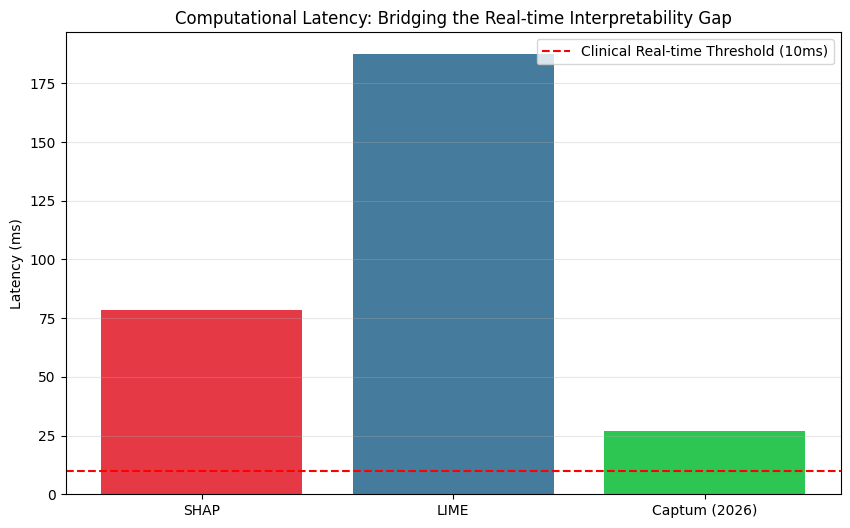

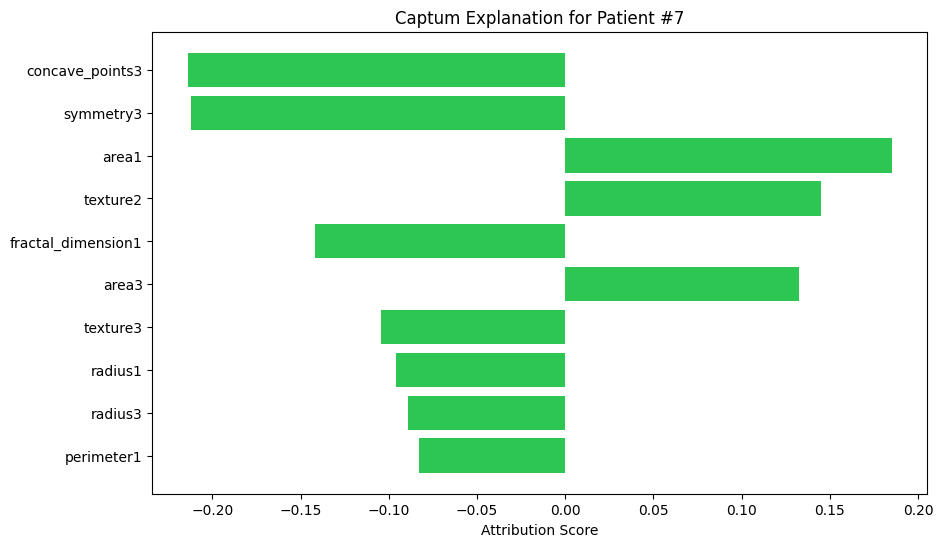


      ✓ Visualizations Generated Successfully!
      ✓ Milestone 2 Code Architecture Complete. Ready for Report Documentation.


In [8]:
# [Cell 6] Final Visualizations & Clinical Reports
import matplotlib.pyplot as plt
import numpy as np

# 1. Latency Comparison Chart (Crucial for Milestone 2)
tools = ['SHAP', 'LIME', 'Captum (2026)']
latencies = [shap_latency, lime_latency, captum_latency]

plt.figure(figsize=(10, 6))
bars = plt.bar(tools, latencies, color=['#E63946', '#457B9D', '#2DC653'])
plt.axhline(10, color='red', linestyle='--', label='Clinical Real-time Threshold (10ms)')
plt.ylabel('Latency (ms)')
plt.title('Computational Latency: Bridging the Real-time Interpretability Gap')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# 2. Captum Feature Importance (Local Attribution)
# Convert Captum attributes to numpy for plotting
attr_np = captum_attr.squeeze().detach().numpy()
top_idx = np.argsort(np.abs(attr_np))[-10:] # Top 10 features

plt.figure(figsize=(10, 6))
plt.barh([feature_names[i] for i in top_idx], attr_np[top_idx], color='#2DC653')
plt.xlabel('Attribution Score')
plt.title(f'Captum Explanation for Patient #{patient_idx}')
plt.show()

print("\n      ✓ Visualizations Generated Successfully!")
print("      ✓ Milestone 2 Code Architecture Complete. Ready for Report Documentation.")